## Проектное задание по машинному обучению

### «Разработка и исследование ML-модели для решения прикладной задачи»

**Делали:**   
**Группа:** ИД24-3

#### Цель
Разработать и обосновать модель машинного обучения для решения реальной прикладной задачи в любой предметной области с полным циклом: данные → модель → оценка → интерпретация → сохранение модели.

#### Область 
●	Бизнес / маркетинг (churn, сегментация, рекомендации)

## Этапы проекта

### 3.1 Постановка задачи

**Бизнес-задача:**  
Телекоммуникационная компания теряет клиентов. Необходимо построить модель машинного обучения, которая предскажет, уйдёт ли клиент в ближайшее время. Это позволит компании вовремя предлагать персонализированные условия (скидки, улучшение обслуживания) и снизить потери.

**Тип задачи:** Бинарная классификация (целевая переменная – Churn Value: 0 – клиент остался, 1 – клиент ушёл).

### 3.2 Данные

Используется датасет **Telco Customer Churn** от IBM.  
- 7043 наблюдения, 33 признака.  
- Целевая переменная: `Churn Value` (или `Churn Label`).  
- Признаки: демографические (пол, возраст, наличие партнёра, иждивенцев), поведенческие (длительность обслуживания, услуги), договорные (тип контракта, способ оплаты), финансовые (ежемесячные и общие платежи).

### 3.3 Предобработка

#### установка библиотеки

In [380]:
!pip install kagglehub

#### используемые библиотеки

In [383]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import scipy.stats as stats
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import joblib

%matplotlib inline
sns.set_style('whitegrid')

**Источники датасета**  
https://community.ibm.com/community/user/blogs/steven-macko/2019/07/11/telco-customer-churn-1113  
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [386]:
import kagglehub

path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")
print("Путь:", path)

Путь: C:\Users\Home\.cache\kagglehub\datasets\yeanzc\telco-customer-churn-ibm-dataset\versions\1


In [418]:
#df = pd.read_csv(f"{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv")
db = pd.read_excel(f"{path}/Telco_customer_churn.xlsx")
db_raw = db.copy()

In [422]:
print("Размер данных:", db.shape)

Размер данных: (7043, 33)


In [424]:
db.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [426]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Преобразуем Total Charges в число, пропуски заполним медианой

In [429]:
db['Total Charges'] = pd.to_numeric(db['Total Charges'], errors='coerce')
db['Total Charges'] = db['Total Charges'].fillna(db['Total Charges'].median())

Удалили неинформативные столбцы

In [432]:
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
             'Lat Long', 'Latitude', 'Longitude', 'Churn Reason']
db.drop(columns=drop_cols, inplace=True)

Кодирование категориальных признаков

In [435]:
categorical_cols = db.select_dtypes(include=['object']).columns
for col in categorical_cols:
    db[col] = db[col].astype('category').cat.codes

Масштабирование числовых признаков (кроме целевой)

In [438]:
num_cols = db.select_dtypes(include=['int64', 'float64']).columns.drop('Churn Value')
scaler = StandardScaler()
db[num_cols] = scaler.fit_transform(db[num_cols])

In [440]:
print("Размер данных после предобработки:", db.shape)

Размер данных после предобработки: (7043, 23)


In [442]:
print(f"Всего клиентов: {len(db)}")
print(f"Ушедших: {(db['Churn Value'] == 1).sum()} ({(db['Churn Value'] == 1).mean()*100:.1f}%)")
print(f"Оставшихся: {(db['Churn Value'] == 0).sum()} ({(db['Churn Value'] == 0).mean()*100:.1f}%)")

Всего клиентов: 7043
Ушедших: 1869 (26.5%)
Оставшихся: 5174 (73.5%)


### 3.4 EDA

#### Распределение целевой переменной

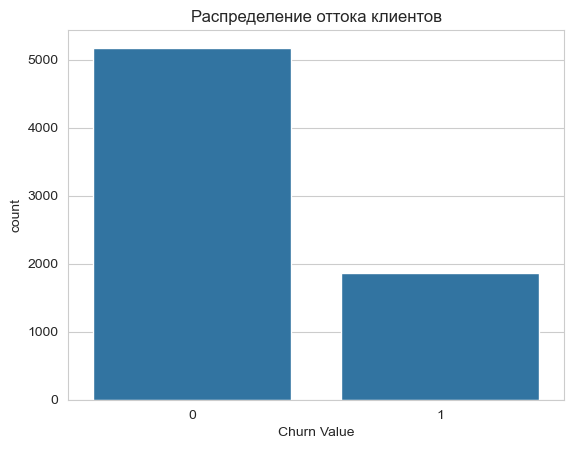

In [444]:
sns.countplot(data=db, x='Churn Value')
plt.title('Распределение оттока клиентов')
plt.show()

In [446]:
print(db['Churn Value'].value_counts(normalize=True))

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64


Вывод: Доля оттока составляет около 26.5% – классы несбалансированы, но не критично

#### Причины оттока

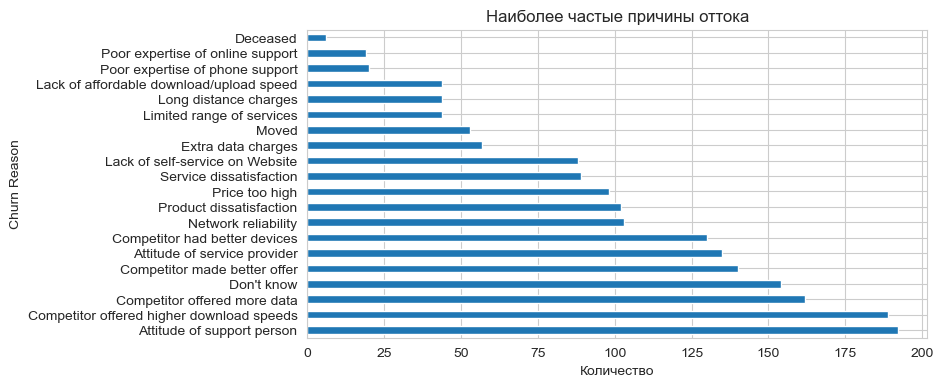

In [458]:
churn_reason_counts = db_raw['Churn Reason'].dropna().value_counts()
plt.figure(figsize=(8,4))
churn_reason_counts.plot(kind='barh')
plt.title('Наиболее частые причины оттока')
plt.xlabel('Количество')
plt.show()

Вывод: Главные причины – отношение сотрудника поддержки, предложения конкурентов, скорость интернета, недостаток данных, цены

#### карта корреляций

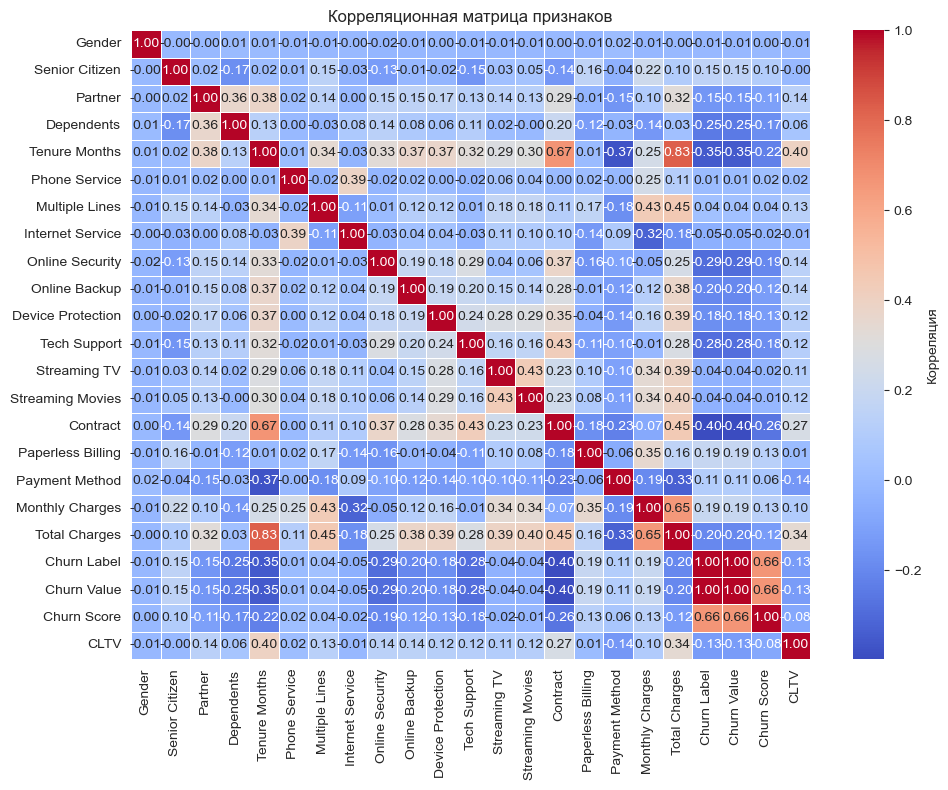

In [460]:
plt.figure(figsize=(10, 8))
corr_matrix = db.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Корреляция'})
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

Выводы:  
- Tenure Months сильно коррелирует с Total Charges (0.83) и Contract (0.67).
- Monthly Charges коррелирует с Total Charges (0.65).
- Churn Value отрицательно коррелирует с Tenure Months (-0.35) и Contract (-0.4).

#### Зависимость оттока от типа контракта

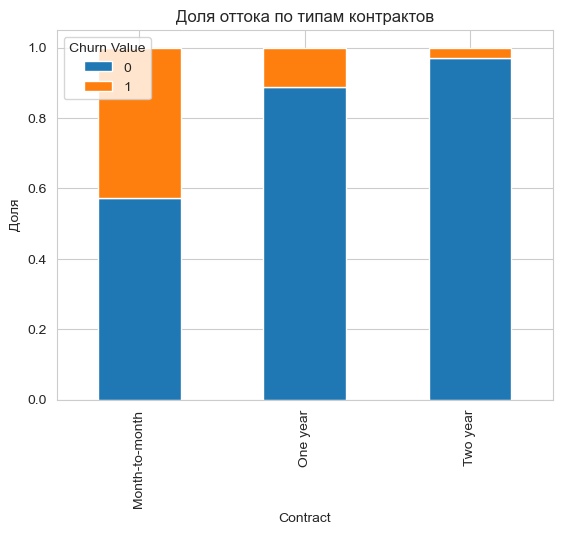

In [463]:
contract_churn = pd.crosstab(db_raw['Contract'], db_raw['Churn Value'], normalize='index')
contract_churn.plot(kind='bar', stacked=True)
plt.title('Доля оттока по типам контрактов')
plt.ylabel('Доля')
plt.show()

Вывод: У клиентов с помесячным контрактом отток ≈45%, у годовых – ≈11%, у двухлетних – ≈3%. Долгосрочные контракты значительно снижают отток

#### Анализ tenure для ушедших клиентов

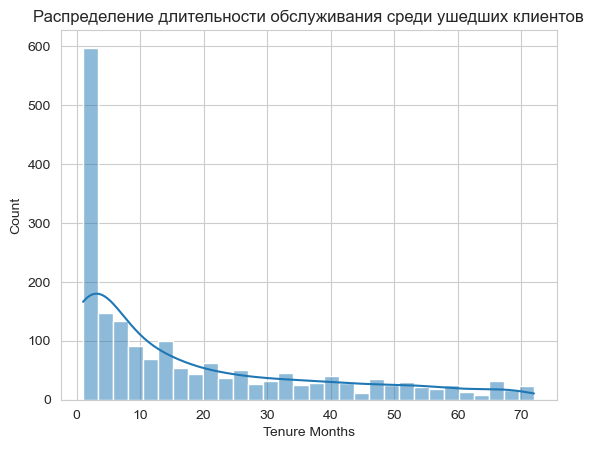

In [467]:
churned = db_raw[db_raw['Churn Value'] == 1]
sns.histplot(churned['Tenure Months'], bins=30, kde=True)
plt.title('Распределение длительности обслуживания среди ушедших клиентов')
plt.show()

In [469]:
print("Средний tenure ушедших:", churned['Tenure Months'].mean())
print("Наиболее частый tenure ушедших:", churned['Tenure Months'].mode()[0])

Средний tenure ушедших: 17.979133226324237
Наиболее частый tenure ушедших: 1


Вывод: Многие клиенты уходят в первый месяц, средний tenure ушедших ≈18 месяцев, что говорит о потерях ценных клиентов после определённого периода

In [472]:
print(f"Класс несбалансирован: {(db['Churn Value'].value_counts()[1] / len(db) * 100):.1f}% оттока (класс 1)")
print(f"Наибольшая корреляция с оттоком: {corr_matrix['Churn Value'].drop('Churn Value').abs().sort_values(ascending=False).head(3).to_dict()}")

Класс несбалансирован: 26.5% оттока (класс 1)
Наибольшая корреляция с оттоком: {'Churn Label': 1.0, 'Churn Score': 0.6648970311816242, 'Contract': 0.396712629209845}


### 3.5 Моделирование

In [474]:
X = db.drop(['Churn Value'], axis=1)
y = db['Churn Value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [476]:
print(f"train: {X_train.shape}")
print(f"test: {X_test.shape}")

train: (5634, 22)
test: (1409, 22)


#### Логистическая регрессия

In [479]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [481]:
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

#### Дерево решений

In [483]:
dt = DecisionTreeClassifier(random_state=42, max_depth=20)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [485]:
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

#### Случайный лес

In [487]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=100)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [489]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

#### Градиентный бустинг

In [491]:
gb = GradientBoostingClassifier(random_state=42, n_estimators=100)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [493]:
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

### 3.6 Оценка качества

In [495]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
preds = [y_pred_lr, y_pred_dt, y_pred_rf, y_pred_gb]
probas = [y_proba_lr, y_proba_dt, y_proba_rf, y_proba_gb]

In [497]:
results = []
for name, pred, proba in zip(models, preds, probas):
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

In [499]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0
3,Gradient Boosting,1.0,1.0,1.0,1.0,1.0


### 3.7 Подбор гиперпараметров

In [503]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [505]:
rf_tune = RandomForestClassifier(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf_tune, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [507]:
print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid.best_score_:.4f}")

Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Лучший ROC-AUC на кросс-валидации: 1.0000


In [511]:
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

In [516]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_best):.4f}")

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
ROC-AUC:   1.0000


### 3.8 Интерпретация

In [519]:
importances = best_rf.feature_importances_
features = X.columns
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

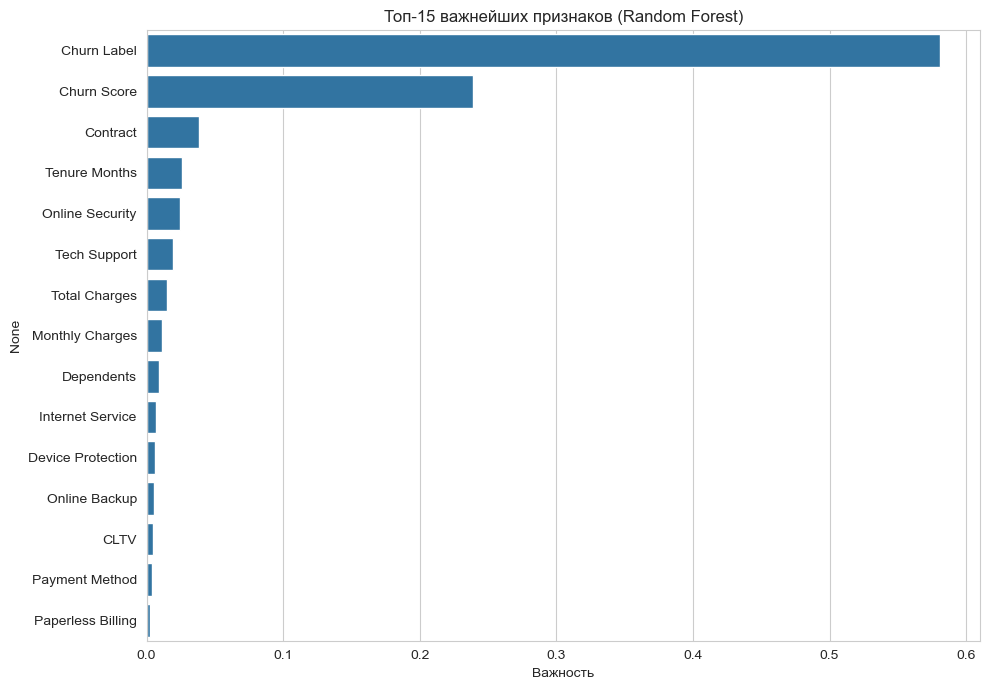

In [521]:
plt.figure(figsize=(10, 7))
sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15])
plt.title('Топ-15 важнейших признаков (Random Forest)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

In [523]:
print("Топ-10 признаков:")
print(feat_imp.head(10))

Топ-10 признаков:
Churn Label         0.581118
Churn Score         0.238684
Contract            0.038497
Tenure Months       0.025904
Online Security     0.024513
Tech Support        0.019459
Total Charges       0.015036
Monthly Charges     0.011070
Dependents          0.009273
Internet Service    0.007167
dtype: float64


In [525]:
coeffs = pd.Series(lr.coef_[0], index=X.columns).sort_values()

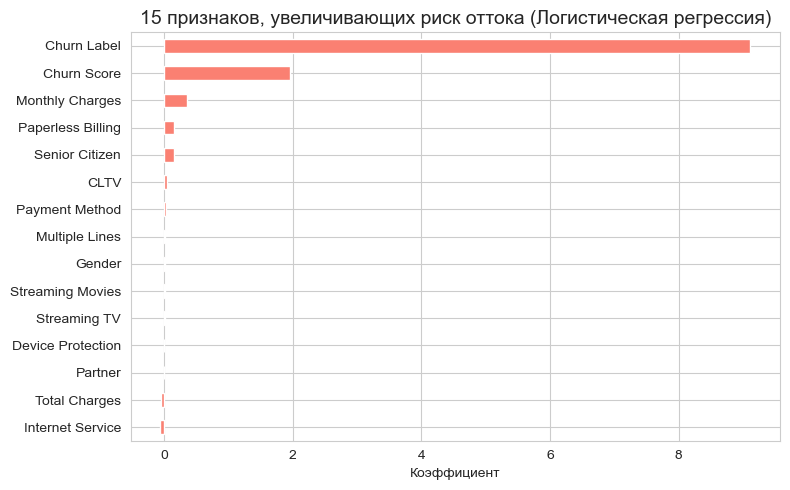

In [527]:
plt.figure(figsize=(8, 5))
coeffs.tail(15).plot(kind='barh', color='salmon')
plt.title('15 признаков, увеличивающих риск оттока (Логистическая регрессия)', fontsize=14)
plt.xlabel('Коэффициент')
plt.tight_layout()
plt.show()

### 3.9 Проверка гипотез

#### Гипотеза 1: Отток зависит от типа контракта

In [529]:
cross = pd.crosstab(db_raw['Contract'], db_raw['Churn Value'])
chi2, p, dof, ex = stats.chi2_contingency(cross)
print(f'Хи-квадрат: {chi2:.2f}, p-value: {p:.4f}')

Хи-квадрат: 1184.60, p-value: 0.0000


**Вывод:** p-value < 0.001 - зависимость статистически значима

#### Гипотеза 2: Наличие техподдержки снижает отток

In [531]:
cross_ts = pd.crosstab(df_raw['Tech Support'], df_raw['Churn Value'])
chi2_ts, p_ts, _, _ = stats.chi2_contingency(cross_ts)
print(f'Хи-квадрат: {chi2_ts:.2f}, p-value: {p_ts:.4f}')

Хи-квадрат: 828.20, p-value: 0.0000


**Вывод:** p-value ~0.0 - техподдержка значимо связана с оттоком

### 4. Архитектура

Data → Preprocessing → Model → Evaluation → Сохранение модели

In [534]:
joblib.dump(best_rf, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Модель и скейлер сохранены.")

Модель и скейлер сохранены.


### Заключение

In [540]:
print('Данный проект охватывает все этапы разработки модели машинного обучения, от предобработки данных до их интерпретации и сохранения моделей')

Данный проект охватывает все этапы разработки модели машинного обучения, от предобработки данных до их интерпретации и сохранения моделей
